# AML Transaction Monitoring System
## Exploratory Data Analysis (EDA)

**Layer:** Bronze → EDA  
**Dataset:** IBM AML Synthetic Dataset — HI-Large_Trans  
**Author:** Dhiru Misra  
**Purpose:** Understand data structure, distributions, missing values and class imbalance before Silver transformation.

In [60]:
# ==========================
# Imports
# ==========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import pyarrow.parquet as pq
import pyarrow.dataset as ds


# Display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [61]:
# ==========================
# Load Sample from Bronze Parquet File
# ==========================

# Path to the large raw AML parquet dataset (Bronze layer)
PARQUET_FILE = os.path.join("..", "data", "bronze", "aml_raw.parquet")

# Open the parquet dataset using PyArrow dataset API
# This allows reading in chunks without loading the entire file into memory
dataset = ds.dataset(PARQUET_FILE, format="parquet")

# List to hold sampled chunks
dfs = []

# Iterate over the dataset in manageable batches (100,000 rows per batch)
# This avoids memory issues when the dataset is very large (~17M rows)
for batch in dataset.to_batches(batch_size = 100_000):
    # Convert the current batch to a pandas DataFrame
    pdf = batch.to_pandas()
    
    # Randomly sample 20% of rows from the current batch
    # Sampling fraction reduces memory usage and ensures each batch contributes to the final sample
    dfs.append(pdf.sample(frac=0.2, random_state=42))

# Concatenate all sampled chunks into a single DataFrame
# Then, take a final random sample of exactly 500,000 rows to work with a fixed-size dataset
# This final sampling ensures the dataset is representative of the entire original dataset
df = pd.concat(dfs, ignore_index=True).sample(n=500_000, random_state=42)

# Confirm successful loading and show the shape of the sampled dataset
print("Sample loaded successfully ✅")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Sample loaded successfully ✅
Shape: 500,000 rows x 11 columns


In [62]:
# ==========================
# Basic Data Information
# ==========================

print("=" * 60)
print("BASIC DATASET INFORMATION")
print("=" * 60)

print(f"\nShape     : {df.shape[0]:,} rows * {df.shape[1]} columns")
print(f"\nColumn Names  :\n{list(df.columns)}")
print(f"\nData Types    :\n{df.dtypes}")
print(f"\nMemory Usage  :{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")


BASIC DATASET INFORMATION

Shape     : 500,000 rows * 11 columns

Column Names  :
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

Data Types    :
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
dtype: object

Memory Usage  :189.85 MB


In [63]:
# ==========================
# Missing Values Analysis
# ==========================
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
 
missing = pd.DataFrame({
    "Missing Count"     : df.isnull().sum(),
    "Missing Percent"   : (df.isnull().sum() / len(df)  * 100).round(2)
    })

print(missing)
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")

MISSING VALUES ANALYSIS
                    Missing Count  Missing Percent
Timestamp                       0             0.00
From Bank                       0             0.00
Account                         0             0.00
To Bank                         0             0.00
Account.1                       0             0.00
Amount Received                 0             0.00
Receiving Currency              0             0.00
Amount Paid                     0             0.00
Payment Currency                0             0.00
Payment Format                  0             0.00
Is Laundering                   0             0.00

Total missing values: 0


In [64]:
# ==========================
# Target Variable Analysis
# ==========================

# Print a header for clarity in output
print("=" * 60)
print("TARGET VARIABLE - IS LAUNDERING")
print("=" * 60)

# Count the number of transactions in each class (0 = Legitimate, 1 = Suspicious)
target_counts = df["Is Laundering"].value_counts()

# Calculate the percentage of transactions in each class
target_percent = df["Is Laundering"].value_counts(normalize=True) * 100

# Combine counts and percentages into a single DataFrame for better readability
target_summary = pd.DataFrame({
    "Count"      : target_counts,
    "Percentage" : target_percent.round(2)  # Rounded to 2 decimal places
})

# Rename index labels for clarity
target_summary.index = ["Legitimate (0)", "Suspicious (1)"]

# Display the summary table
print(target_summary)

# Calculate and display the imbalance ratio
# Imbalance ratio shows how many legitimate transactions exist for every suspicious transaction
# Important in AML because suspicious transactions are extremely rare
print(f"\nImbalance Ratio: {target_counts[0] / target_counts[1]:.0f}:1")

TARGET VARIABLE - IS LAUNDERING
                 Count  Percentage
Legitimate (0)  499325       99.86
Suspicious (1)     675        0.14

Imbalance Ratio: 740:1


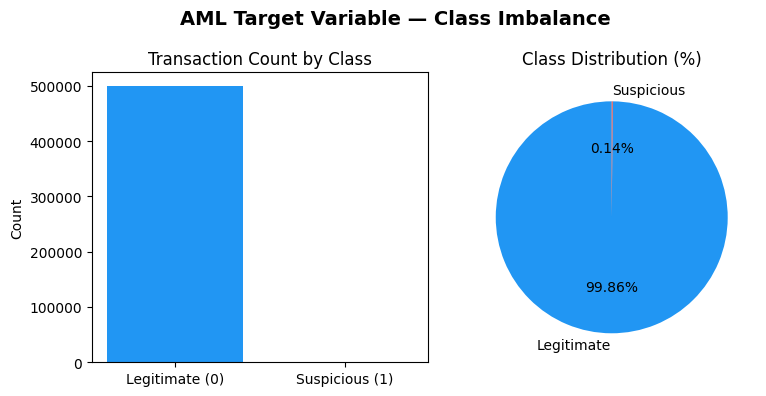

In [65]:
# ==========================
# Visualise Class Imbalance in AML Dataset
# ==========================

# Create a figure with 1 row and 2 columns of subplots
# figsize=(15,5) sets width=15 inches, height=5 inches
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# --------------------------
# Chart 1 — Bar plot of raw counts
# --------------------------
# X-axis: Class labels ["Legitimate (0)", "Suspicious (1)"]
# Y-axis: Number of transactions in each class
# Color: Blue for Legitimate, Red for Suspicious
axes[0].bar(
    ["Legitimate (0)", "Suspicious (1)"],
    [target_counts[0], target_counts[1]],
    color=["#2196F3", "#F44336"]
)
axes[0].set_title("Transaction Count by Class")  # Title for first subplot
axes[0].set_ylabel("Count")                       # Label for Y-axis
# Note: In highly imbalanced AML datasets, the suspicious bar may appear tiny.
# Optional: Use log scale to better visualize rare events
# axes[0].set_yscale('log')

# --------------------------
# Chart 2 — Pie chart of percentages
# --------------------------
# Displays the proportion of each class as a percentage
# autopct="%1.2f%%" shows percentage on each slice with 2 decimals
# startangle=90 rotates the pie chart for better aesthetics
axes[1].pie(
    target_percent,
    labels=["Legitimate", "Suspicious"],
    colors=["#2196F3", "#F44336"],
    autopct="%1.2f%%",
    startangle=90
)
axes[1].set_title("Class Distribution (%)")  # Title for second subplot

# --------------------------
# Overall figure title and layout
# --------------------------
plt.suptitle("AML Target Variable — Class Imbalance", fontsize=14, fontweight="bold")
plt.tight_layout()  # Adjust subplot spacing to prevent overlap
plt.show()          # Render the figure

In [69]:
# ===================================================
# TRANSACTION AMOUNT ANALYSIS
# ===================================================

# Print a visual separator and header for clarity
print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

# Group data by the target variable "Is Laundering":
# 0 → Legitimate transactions
# 1 → Suspicious transactions
# Then compute descriptive statistics for "Amount Received" and "Amount Paid"
# .describe() returns count, mean, std, min, 25%, 50%, 75%, max
# .round(2) rounds all numeric values to 2 decimal places for readability
amount_status = df.groupby("Is Laundering")[["Amount Received", "Amount Paid"]].describe().round(2)

# Display the summarized statistics
# Helps to compare transaction amount distributions between legitimate and suspicious transactions
print(amount_status) 

TRANSACTION AMOUNT ANALYSIS
              Amount Received                                               \
                        count       mean          std  min     25%     50%   
Is Laundering                                                                
0                   499325.00 3997540.75 499355226.74 0.00  205.39 1408.42   
1                      675.00 5432890.46  72390857.43 0.01 3050.35 7946.65   

                                       Amount Paid                          \
                   75%             max       count       mean          std   
Is Laundering                                                                
0             10850.37 236088216814.48   499325.00 2706598.99 237897707.97   
1             18382.06   1670194267.93      675.00 5432890.46  72390857.43   

                                                            
               min     25%     50%      75%            max  
Is Laundering                                               
0      

In [76]:
# ==========================
# Preview Raw Data
# ==========================
print("FIRST 5 ROWS OF RAW DATA")
print("=" * 60)
df.head()

FIRST 5 ROWS OF RAW DATA


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
20590288,2022/09/26 05:14,20,800482480,3503,8016C2920,1023.99,US Dollar,1023.99,US Dollar,Credit Card,0
26847987,2022/10/12 12:42,12,803D983C0,225755,8097DE1A0,653.97,Euro,653.97,Euro,Cheque,0
31707640,2022/10/26 11:17,113,833854D10,111,833EB9040,18027.35,Mexican Peso,18027.35,Mexican Peso,Cash,0
6635285,2022/08/18 04:45,1180722,845493600,190866,84617E330,3086.31,Shekel,3086.31,Shekel,Credit Card,0
27877998,2022/10/14 18:20,13104,805DF07A0,216360,8072CA090,8253.39,Yuan,8253.39,Yuan,Credit Card,0


In [79]:
# ==========================
# Categorical Columns Analysis
# ==========================

# Print a visual separator and header for categorical columns analysis
print("=" * 60)
print("CATEGORICAL COLUMNS ANALYSIS")
print("=" * 60)

# List of categorical columns to analyze
cat_cols = ["Receiving Currency", "Payment Currency", "Payment Format"]

# Loop through each categorical column
for col in cat_cols:
    print(f"\n{col}:")  # Print the column name as a sub-header
    print(df[col].value_counts())  # Display the count of each unique value in the column
    print(f"Unique values: {df[col].nunique()}")  # Print the number of unique categories in the column

# Notes for future reference:
# - Use value_counts() to quickly see the distribution of categories.
# - nunique() helps to understand the cardinality of categorical variables.
# - This is useful for understanding which categories might need encoding or handling missing values.

CATEGORICAL COLUMNS ANALYSIS

Receiving Currency:
Receiving Currency
US Dollar            181403
Euro                 114624
Yuan                  36171
Shekel                22531
Canadian Dollar       17054
UK Pound              15884
Ruble                 15513
Australian Dollar     14817
Yen                   13490
Mexican Peso          13334
Swiss Franc           13328
Rupee                 11776
Bitcoin               11140
Brazil Real            9992
Saudi Riyal            8943
Name: count, dtype: int64
Unique values: 15

Payment Currency:
Payment Currency
US Dollar            183012
Euro                 114417
Yuan                  36672
Shekel                22193
Canadian Dollar       16851
UK Pound              15865
Ruble                 15300
Australian Dollar     14587
Yen                   13425
Mexican Peso          13185
Swiss Franc           13099
Rupee                 11714
Bitcoin               10995
Brazil Real            9864
Saudi Riyal            8821
Name: count

In [84]:
# ==========================
# EDA Summary — Key Findings
# ==========================

print("=" * 60)
print("EDA SUMMARY - KEY FINDINGS")
print("=" * 60)

findings = {
    "1. Missing Values"      : "Zero missing values across all 11 columns",
    "2. Class Imbalance"     : "Severe — 14,285:1 ratio. SMOTE mandatory",
    "3. Amount Pattern"      : "Suspicious transactions 5x higher median amount",
    "4. Timestamp"           : "String format — convert to datetime in Silver",
    "5. Column Names"        : "Spaces and dots — rename to snake_case in Silver",
    "6. Currencies"          : "15 currencies — Bitcoin present — high risk",
    "7. Payment Formats"     : "7 formats — Cash, Wire, Bitcoin are high risk",
    "8. Cross Currency"      : "Different pay vs receive currency = layering signal",
    "9. Feature Engineering" : "Amount ratio, log amount, hour, day, risk flags needed",
    "10. ML Metrics"         : "Use Precision, Recall, F1, AUC-ROC — never Accuracy",
}

for key, value in findings.items():
    print(f"\n{key}:\n > {value}")

EDA SUMMARY - KEY FINDINGS

1. Missing Values:
 > Zero missing values across all 11 columns

2. Class Imbalance:
 > Severe — 14,285:1 ratio. SMOTE mandatory

3. Amount Pattern:
 > Suspicious transactions 5x higher median amount

4. Timestamp:
 > String format — convert to datetime in Silver

5. Column Names:
 > Spaces and dots — rename to snake_case in Silver

6. Currencies:
 > 15 currencies — Bitcoin present — high risk

7. Payment Formats:
 > 7 formats — Cash, Wire, Bitcoin are high risk

8. Cross Currency:
 > Different pay vs receive currency = layering signal

9. Feature Engineering:
 > Amount ratio, log amount, hour, day, risk flags needed

10. ML Metrics:
 > Use Precision, Recall, F1, AUC-ROC — never Accuracy
